In [1]:
import base64
import re
import textwrap
from io import BytesIO
from pathlib import Path
import os

from altair import TOPLEVEL_ONLY_KEYS

os.environ["HF_HOME"] = r"D:\Workspace\RAG_Integration\SamplePDF\hf_cache"

import numpy as np
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, RapidOcrOptions, PaginatedPipelineOptions, TableStructureOptions, smolvlm_picture_description
from docling.document_converter import DocumentConverter, WordFormatOption, PdfFormatOption
from dotenv import load_dotenv
from IPython.display import HTML, display
from ollama import chat
from PIL import Image
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity



D:\Workspace\RAG_Integration\RAG_System_Unified_Search_Engine\PDF_Extrating\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PdfPipelineOptions :- This is the main configuration class for the standard PDF pipeline. It controls almost every step involved in converting a PDF into a DoclingDocument.
RapidOcrOptions :- This configures the RapidOCR engine that Docling uses for OCR. RapidOCR supports different inference backends (such as ONNX Runtime) and lets you specify custom detection, recognition, and orientation models.
smolvlm_picture_description :- This is not a class. It is a preconfigured object for picture description using the SmolVLM vision-language model. Specifically, it is a PictureDescriptionVlmOptions instance configured to use the Hugging Face model HuggingFaceTB/SmolVLM-256M-Instruct

load_dotenv() is a function from the Python package python-dotenv. It loads environment variables defined in a .env file into your application's environment, allowing you to access them with os.getenv() or os.environ.

In [2]:
load_dotenv()

False

Convert PDF to Markdown

Document converter can be used for PDF as well as DOCX. 

In [3]:
table_structure_option= TableStructureOptions(
    do_cell_matching = True
)
pipeline_option = PdfPipelineOptions (
    generate_page_images=True,
    images_scale=1.00,
    do_ocr=True,
    do_picture_description=True,
    ocr_options=RapidOcrOptions(),
    do_table_structure=True,
    table_structure_options = table_structure_option,
    picture_description_options=smolvlm_picture_description
)

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_option
        ),
        InputFormat.DOCX: WordFormatOption(),   # default options
    }
)
document_path = Path=("data/Sample.pdf")
document_path

'data/Sample.pdf'

In [4]:
%%time
result = converter.convert(document_path)


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
Loading weights: 100%|██████████| 471/471 [00:00<00:00, 4419.18it/s]
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-07-04 17:28:57,336 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-04 17:28:57,466 [RapidOCR] download_file.py:60: File exists and is valid: D:\Workspace\RAG_Integration\RAG_System_Unified_Search_Engine\PDF_Extrating\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-04 17:28:57,467 [RapidOCR] main.py:63: Using D:\Workspace\RAG_Integration\RAG_System_Unified_Search_Engine\PDF_Extrating\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-

CPU times: total: 2min 6s
Wall time: 1min 29s


In [5]:
from copy import deepcopy


def normalize_duplicate_header(table_item):
    """
    Remove a duplicated spanning header such as

        GAAP | GAAP | GAAP | GAAP

    from the first row of a Docling TableItem.
    """

    new_table = deepcopy(table_item)

    cells = []

    # Collect cells except duplicated first-row header
    for cell in new_table.data.table_cells:

        # Remove first row
        if cell.start_row_offset_idx == 0:

            if cell.text.strip():
                continue

        # Shift remaining rows up by one
        cell.start_row_offset_idx -= 1
        cell.end_row_offset_idx -= 1

        cells.append(cell)

    new_table.data.table_cells = cells
    new_table.data.num_rows -= 1

    return new_table
    

In [6]:
"""
Problem with iterative table need to fix in future. 

doc
  Value error, Document hierarchy is inconsistent. #/tables/4 has child #/texts/9 with parent
    #/body [type=value_error, input_value=DoclingDocument(schema_na...5CYII=')), page_no=10)}), input_type=DoclingDocument]

    Do not use replace_item() for TableItem unless you also update the document hierarchy.
    When you deep-copied the TableItem, those child TextItems still belonged to the original document. After replacing the table, the hierarchy became inconsistent:
"""

"""for table in result.document.tables:

    fixed_table = normalize_duplicate_header(table)

    result.document.replace_item(
        old_item=table,
        new_item=fixed_table
    ) """
    
documents = result.document
print(documents.export_to_markdown(page_no=1))


<!-- image -->

## NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025

- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago
- Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago
- Record full-year revenue of $130.5 billion, up 114%

NVIDIA (NASDAQ: NVDA) today reported revenue for the fourth quarter ended January 26, 2025, of $39.3 billion, up 12% from the previous quarter and up 78% from a year ago.

For the quarter, GAAP earnings per diluted share was $0.89, up 14% from the previous quarter and up 82% from a year ago. Non-GAAP earnings per diluted share was $0.89, up 10% from the previous quarter and up 71% from a year ago.

For fiscal 2025, revenue was $130.5 billion, up 114% from a year ago. GAAP earnings per diluted share was $2.94, up 147% from a year ago. Non-GAAP earnings per diluted share was $2.99, up 130% from a year ago.

'Demand for Blackwell is amazing as reasoning AI adds an

Create Visual inspection of generated document with Markdown. 

In [7]:
def image_to_base64(image : Image.Image) -> str:
    buffer = BytesIO()
    image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

def display_page(content: str, image: Image):
    html_templete=f"""
        <div style="display:flex; align-items:flex-start; gap: 40px; front-family: monospace;">
            <div style="flex:1 max-width: 45%;">
                <img src="data:image/png;base64,{image_to_base64(image)}" style=width:100%; height: auto; padding 5px;">
            </div>
            <div style="flex:1 max-width: 45%; white-space:pre-warp; padding:10px">
                <div style="word-warp: break-word; max-width:120ch;">
                    {content}
                </div>
            </div>
        </div>
    """
    display(HTML(html_templete))


In [8]:
n_page = len(documents.pages)
n_page

10

In [9]:
pages = []
for page_num in range(1, n_page+1):
    pages.append(
        (
            documents.export_to_markdown(page_no = page_num),
            documents.pages[page_num].image.pil_image
        )
    )


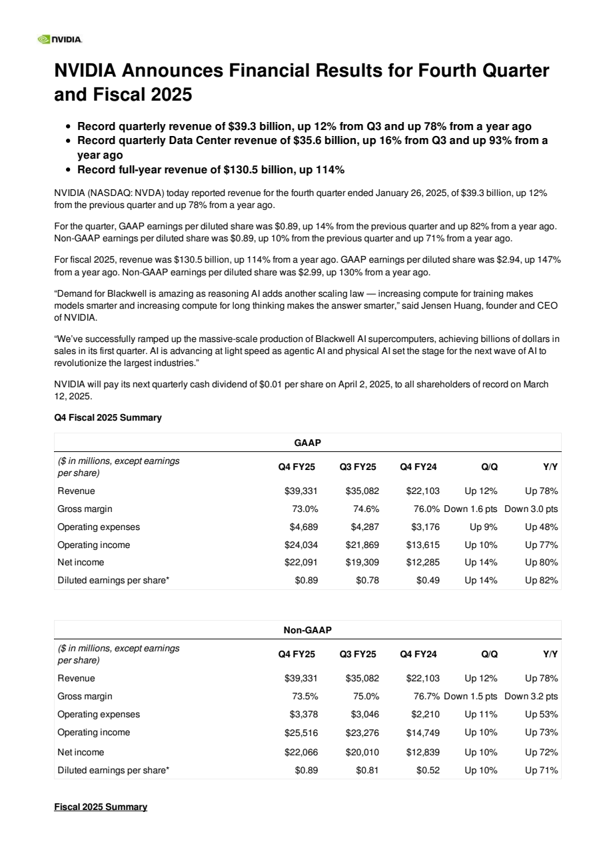

In [10]:
display_page(*pages[0])

**Image Annotations**

Image annotation in Docling (when scraping a PDF) refers to the process of identifying, labeling, and attaching metadata to images extracted from a document—so that those images become meaningful and usable in downstream workflows (e.g., search, LLM processing, or structured data extraction).


In [11]:
annotations = list(map(lambda pic: pic.meta.code.text, filter(lambda pic: pic.meta is not None and pic.meta.code is not None, documents.pictures)))
print(annotations)


[]


** Replacing the image tag with text**

In [12]:
def replace_occurances(text:str, target:str, replacements:list) -> str:
    for replace in replacements:
        if target in text:
            text = text.replace(target, replace, 1)
        else:
            raise ValueError(f"No more occurance of {target} found in the text for {replace}")
    text = text.replace(target, "")
    return text

In [13]:
import re
def replace_paragraph(text:str) -> str:
    text = re.sub(r'\n\s*\n', ' <PARAGRAPH> ', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text


In [14]:
IMAGE_PLACEHOLDER = "<!-- image_placeholder -->"
PAGE_BREAK_PLACEHOLDER = "<!-- page_break_placeholder -->"
text = documents.export_to_markdown(page_break_placeholder=PAGE_BREAK_PLACEHOLDER, image_placeholder=IMAGE_PLACEHOLDER)
print(type(text))


<class 'str'>


In [15]:
replace_occurances(text, IMAGE_PLACEHOLDER, annotations)

"\n\n## NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025\n\n- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago\n- Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago\n- Record full-year revenue of $130.5 billion, up 114%\n\nNVIDIA (NASDAQ: NVDA) today reported revenue for the fourth quarter ended January 26, 2025, of $39.3 billion, up 12% from the previous quarter and up 78% from a year ago.\n\nFor the quarter, GAAP earnings per diluted share was $0.89, up 14% from the previous quarter and up 82% from a year ago. Non-GAAP earnings per diluted share was $0.89, up 10% from the previous quarter and up 71% from a year ago.\n\nFor fiscal 2025, revenue was $130.5 billion, up 114% from a year ago. GAAP earnings per diluted share was $2.94, up 147% from a year ago. Non-GAAP earnings per diluted share was $2.99, up 130% from a year ago.\n\n'Demand for Blackwell is amazing as reasoning AI adds a

## Document Processing Pipeline

Create a method with adding all the above process into single place

In [16]:
def document_processing(document_path: Path, converter: DocumentConverter, n_pages: int =-1) -> str:
    result = converter.convert(source = document_path)
    document = result.document
    annotations = list(map(lambda pic: pic.meta.code.text, filter(lambda pic: pic.meta is not None and pic.meta.code is not None, documents.pictures)))
    text = document.export_to_markdown(page_break_placeholder=PAGE_BREAK_PLACEHOLDER, image_placeholder=IMAGE_PLACEHOLDER)
    text = replace_occurances(text, IMAGE_PLACEHOLDER, annotations)
    #text = replace_paragraph(text=text)
    if n_pages == -1:
        return text
    return PAGE_BREAK_PLACEHOLDER.join(text.split(PAGE_BREAK_PLACEHOLDER)[:n_pages]) # [:n_pages] - Take the first n_pages from split list


In [17]:
%%time
document_text = document_processing(document_path= document_path, converter=converter, n_pages=3)



CPU times: total: 1min 49s
Wall time: 1min 21s


## Token count in parse document

In [18]:
print(len(document_text.split(" ")))
print(document_text)

2977


## NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025

- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago
- Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago
- Record full-year revenue of $130.5 billion, up 114%

NVIDIA (NASDAQ: NVDA) today reported revenue for the fourth quarter ended January 26, 2025, of $39.3 billion, up 12% from the previous quarter and up 78% from a year ago.

For the quarter, GAAP earnings per diluted share was $0.89, up 14% from the previous quarter and up 82% from a year ago. Non-GAAP earnings per diluted share was $0.89, up 10% from the previous quarter and up 71% from a year ago.

For fiscal 2025, revenue was $130.5 billion, up 114% from a year ago. GAAP earnings per diluted share was $2.94, up 147% from a year ago. Non-GAAP earnings per diluted share was $2.99, up 130% from a year ago.

'Demand for Blackwell is amazing as reasoning AI adds another sca

## Chunking Strategy

In [19]:
SPLIT_PATTERN = "\n#"
chunks = document_text.split(SPLIT_PATTERN)
len(chunks)
chunks[1]

"# NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025\n\n- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago\n- Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago\n- Record full-year revenue of $130.5 billion, up 114%\n\nNVIDIA (NASDAQ: NVDA) today reported revenue for the fourth quarter ended January 26, 2025, of $39.3 billion, up 12% from the previous quarter and up 78% from a year ago.\n\nFor the quarter, GAAP earnings per diluted share was $0.89, up 14% from the previous quarter and up 82% from a year ago. Non-GAAP earnings per diluted share was $0.89, up 10% from the previous quarter and up 71% from a year ago.\n\nFor fiscal 2025, revenue was $130.5 billion, up 114% from a year ago. GAAP earnings per diluted share was $2.94, up 147% from a year ago. Non-GAAP earnings per diluted share was $2.99, up 130% from a year ago.\n\n'Demand for Blackwell is amazing as reasoning AI adds anothe

In [20]:
chunk_text= ""
for i, chunk in enumerate(chunks):
    if chunk.startswith("#"):
        chunk = f"#{chunk}"
    chunk_text += f"<|start_chunk_{i}|>\n{chunk}<|end_chunk_{i}|>"

In [21]:
print(chunk_text)


<|start_chunk_0|>

<|end_chunk_0|><|start_chunk_1|>
## NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025

- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from a year ago
- Record quarterly Data Center revenue of $35.6 billion, up 16% from Q3 and up 93% from a year ago
- Record full-year revenue of $130.5 billion, up 114%

NVIDIA (NASDAQ: NVDA) today reported revenue for the fourth quarter ended January 26, 2025, of $39.3 billion, up 12% from the previous quarter and up 78% from a year ago.

For the quarter, GAAP earnings per diluted share was $0.89, up 14% from the previous quarter and up 82% from a year ago. Non-GAAP earnings per diluted share was $0.89, up 10% from the previous quarter and up 71% from a year ago.

For fiscal 2025, revenue was $130.5 billion, up 114% from a year ago. GAAP earnings per diluted share was $2.94, up 147% from a year ago. Non-GAAP earnings per diluted share was $2.99, up 130% from a year ago.

'Demand for Blackwel

## Google Context Aware Trained model.


In [22]:
#MODEL = "huggingface.co/unsloth/Qwen3.6-35B-A3B-GGUF"
MODEL = "qwen3.5:latest"
Temperature = 0.0
MIN_P = 0.0
Repeat_Penalty = 1.0
TOP_K = 64
TOP_P = 0.95



In [23]:
def call_model(prompt: str) -> str:
    response = chat(
        model=MODEL,
        messages=[{"role": "user", "context": prompt}],
        keep_alive = "-1h",
        options={
            "num_ctx":16384,
            "temperature": Temperature,
            "min_p": MIN_P,
            "repeat_penalty":Repeat_Penalty,
            "top_k": TOP_K,
            "top_p": TOP_P
        },
    )
    return response.message.content

In [24]:
CHUNKING_PROMPT = """
You are an assistant specialized in splitting text into semantically consistent sections.
<instructions>
	<instruction>The test has been divided into chunks, each marked with <|start_chunk_X|><|end_chunk_X|> tags, where X is the chunk number</instruction>
	<instruction>Identify points where splits should occur, such that consecutive chunks of similar themes stay together</instruction>
	<instruction>Each chunk must be between 200 and 100 words</instruction>
	<instruction>If chunks 1 and 2 belong together but chunk 3 starts a new topics, suggest a split after chunk 2</instruction>
	<instruction>The chunks must be listed in ascending order</instruction>
	<instruction>Provide your response in the form 'split_after 3, 5'</instruction>
</instructions>
This is the codument text:
<document>
    {document_text}
</document>

Response only with the IDs of the chunks where you beleive a split should occur.
YOU MUST RESPOND WITH AT LEASE ONE SPLIT.
""".strip()

In [25]:
prompt = CHUNKING_PROMPT.format(document_text = chunk_text)
print(prompt)

You are an assistant specialized in splitting text into semantically consistent sections.
<instructions>
	<instruction>The test has been divided into chunks, each marked with <|start_chunk_X|><|end_chunk_X|> tags, where X is the chunk number</instruction>
	<instruction>Identify points where splits should occur, such that consecutive chunks of similar themes stay together</instruction>
	<instruction>Each chunk must be between 200 and 100 words</instruction>
	<instruction>If chunks 1 and 2 belong together but chunk 3 starts a new topics, suggest a split after chunk 2</instruction>
	<instruction>The chunks must be listed in ascending order</instruction>
	<instruction>Provide your response in the form 'split_after 3, 5'</instruction>
</instructions>
This is the codument text:
<document>
    <|start_chunk_0|>

<|end_chunk_0|><|start_chunk_1|>
## NVIDIA Announces Financial Results for Fourth Quarter and Fiscal 2025

- Record quarterly revenue of $39.3 billion, up 12% from Q3 and up 78% from 

In [27]:
%%time
response = call_model(prompt= prompt)
print(response)

Hello! 👋 How can I assist you today? Feel free to ask any questions or let me know if you need help with something specific! 😊
CPU times: total: 15.6 ms
Wall time: 1min 11s


In [28]:
response = call_model(prompt= "What is the NVIDIA Announcement")
print (response)

Hello! 👋 How can I assist you today? Feel free to ask any questions or let me know if you need help with something specific! 😊
